In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, vonmises_fisher
import seaborn as sns
import sys
import glob
from tqdm import trange 

In [3]:
results = "../results/correlations/*.csv"

In [4]:
dfs = list()
for f in glob.glob(results):
    dfs.append(pd.read_csv(f).rename({"Unnamed: 0": "measure"}, axis=1))

In [5]:
all_dfs = pd.concat(dfs)

In [6]:
all_dfs["original vs. corrected on crop"] = np.abs(all_dfs["original vs. corrected on crop"])
all_dfs["original vs. SERN corrected on crop"] = np.abs(all_dfs["original vs. SERN corrected on crop"])
all_dfs["original vs. on crop"] = np.abs(all_dfs["original vs. on crop"])

#all_dfs["original vs. corrected on crop"] -= all_dfs["original vs. on crop"]
#all_dfs["original vs. SERN corrected on crop"] -= all_dfs["original vs. on crop"]

In [9]:
melted = pd.melt(all_dfs, id_vars=["measure", "model", "relative_likelihood", "cap_radius", "graph_type", "coord_type", "n", "k", "radius_factor", "on crop vs. SERN values"], value_name="Pearson corr.", var_name="comparison")

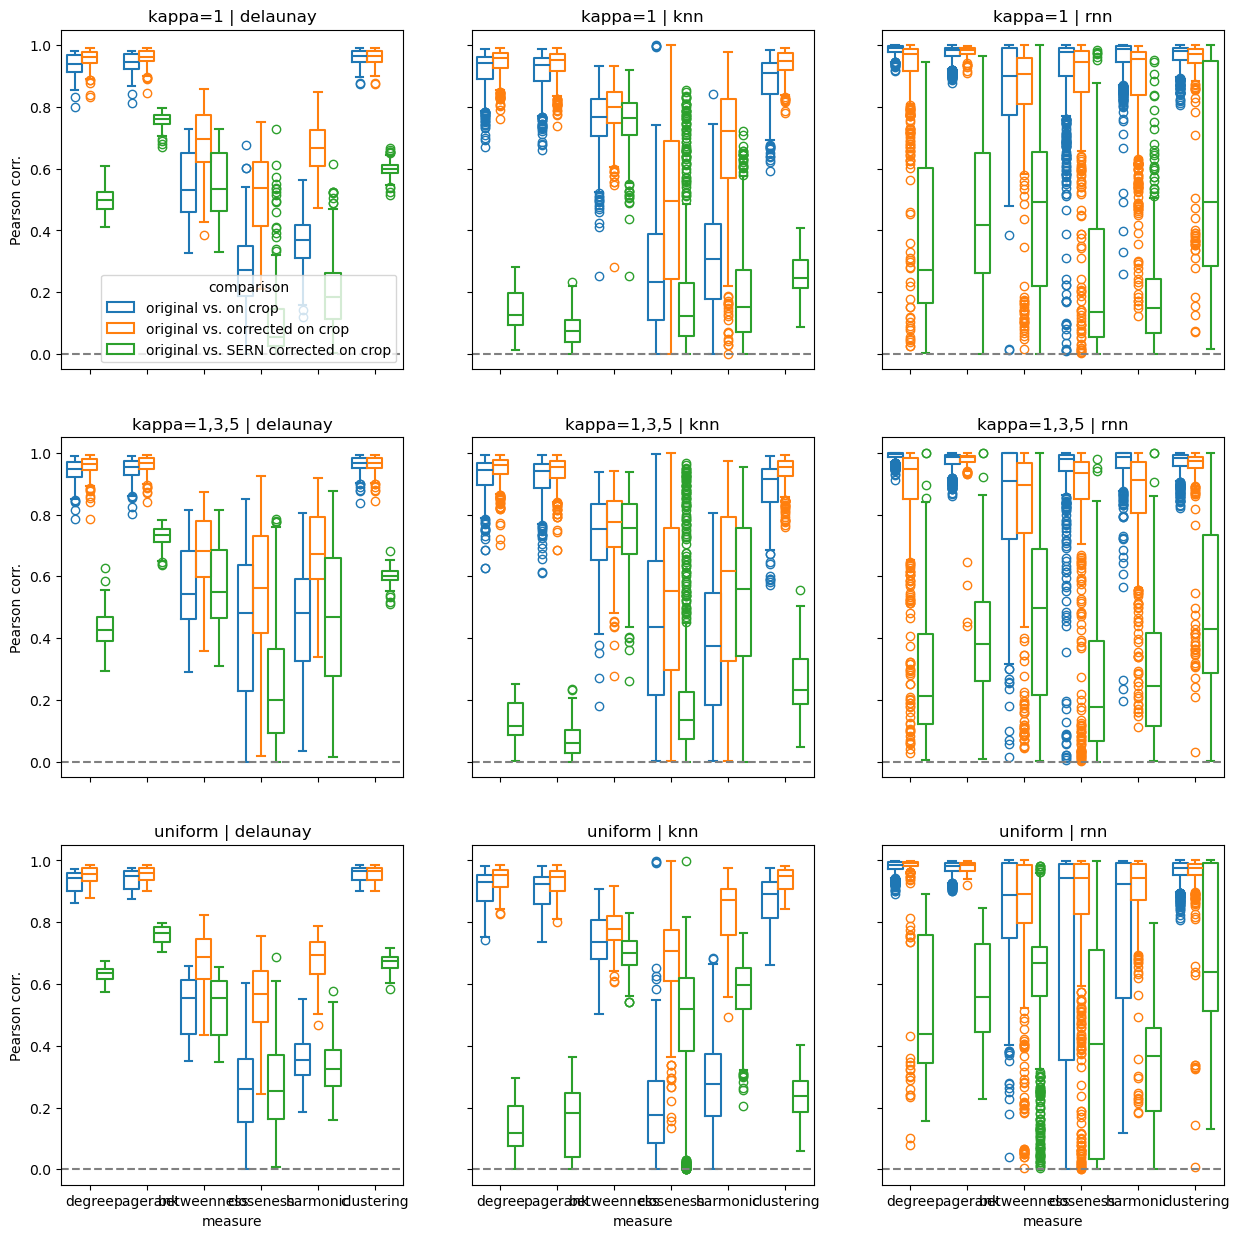

In [11]:
f, axs = plt.subplots(len(melted["coord_type"].unique()), len(melted["graph_type"].unique()), sharex=True, sharey=True, figsize=(15, 15))
i = 0
j = 0
for (coord_type, graph_type), df in melted.groupby(["coord_type", "graph_type"]):
    legend = (i == 0) and (j == 0)
    sns.boxplot(df, x="measure", y="Pearson corr.", hue="comparison", legend=legend, ax=axs[i,j], fill=False) #, cut=0, split=True, inner=None)
    axs[i,j].set_title(f"{coord_type} | {graph_type}")
    axs[i,j].axhline(0, linestyle="--", color="grey")
    j += 1
    if j > 2:
        i += 1
        j = 0